### About Dataset
This dataset provides daily weather information for capital cities around the world. Unlike forecast data, this dataset offers a comprehensive set of features that reflect the current weather conditions around the world.
Starting from August 29, 2023.
It provides over 40+ features , including temperature, wind, pressure, precipitation, humidity, visibility, air quality measurements and more. The dataset is valuable for analyzing Global weather patterns, exploring climate trends, and understanding the relationships between different weather parameters.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_squared_error
from sklearn.preprocessing import LabelEncoder #to improve prediction accuracy
from sklearn.preprocessing import StandardScaler #to standardize the input data
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tqdm as notebook_tqdm

In [2]:
import nbformat
print(nbformat.__version__)

5.10.4


In [3]:
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

%matplotlib inline

In [4]:
df = pd.read_csv("/Users/josh/Desktop/Immanuel/PM-Accelerator/DataScience/data/GlobalWeatherRepository.csv")
df

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150850,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1782971100,2026-07-02 01:45,17.0,62.6,Partly Cloudy,...,18.8,28.2,2,2,06:10 AM,06:53 PM,09:19 PM,08:28 AM,Waning Gibbous,96
150851,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1782971100,2026-07-02 12:45,26.3,79.3,Moderate or heavy rain with thunder,...,17.0,17.3,2,2,05:19 AM,06:42 PM,08:45 PM,07:15 AM,Waning Gibbous,97
150852,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1782970200,2026-07-02 08:30,23.4,74.2,Sunny,...,16.0,61.0,2,2,05:36 AM,06:37 PM,08:49 PM,07:41 AM,Waning Gibbous,97
150853,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1782971100,2026-07-02 07:45,13.6,56.4,Sunny,...,11.0,13.0,1,1,06:34 AM,05:47 PM,08:12 PM,08:34 AM,Waning Gibbous,97


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150855 entries, 0 to 150854
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       150855 non-null  object 
 1   location_name                 150855 non-null  object 
 2   latitude                      150855 non-null  float64
 3   longitude                     150855 non-null  float64
 4   timezone                      150855 non-null  object 
 5   last_updated_epoch            150855 non-null  int64  
 6   last_updated                  150855 non-null  object 
 7   temperature_celsius           150855 non-null  float64
 8   temperature_fahrenheit        150855 non-null  float64
 9   condition_text                150855 non-null  object 
 10  wind_mph                      150855 non-null  float64
 11  wind_kph                      150855 non-null  float64
 12  wind_degree                   150855 non-nul

In [6]:
print(df.describe())


            latitude      longitude  last_updated_epoch  temperature_celsius  \
count  150855.000000  150855.000000        1.508550e+05        150855.000000   
mean       19.236319      21.894452        1.749424e+09            21.328419   
std        24.402384      65.779112        1.938211e+07             9.519016   
min       -41.300000    -175.200000        1.715849e+09           -29.800000   
25%         4.050300      -6.836100        1.732697e+09            16.000000   
50%        17.250000      23.236100        1.749459e+09            23.700000   
75%        40.400000      49.882200        1.766128e+09            27.900000   
max        65.300000     179.220000        1.782971e+09            79.300000   

       temperature_fahrenheit       wind_mph       wind_kph    wind_degree  \
count           150855.000000  150855.000000  150855.000000  150855.000000   
mean                70.392936       7.943285      12.787261     169.421378   
std                 17.134078       7.023295 

### Step 1 Data Cleaning

In [7]:
df.columns = df.columns.str.strip()
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [8]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

df.sort_values('last_updated', inplace=True)

In [9]:
Q1 = df['temperature_celsius'].quantile(0.25)
Q3 = df['temperature_celsius'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

In [10]:
numerical_cols = df.select_dtypes(include="int64").columns

In [11]:
scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [12]:
df.groupby("country")["temperature_celsius"].mean()

country
Afghanistan    19.294588
Albania        19.326744
Algeria        20.207633
Andorra         8.818581
Angola         25.862065
                 ...    
Гватемала      15.900000
Польша         24.200000
Турция         34.000000
كولومبيا       23.100000
火鸡             29.700000
Name: temperature_celsius, Length: 211, dtype: float64

In [13]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

Series([], dtype: int64)

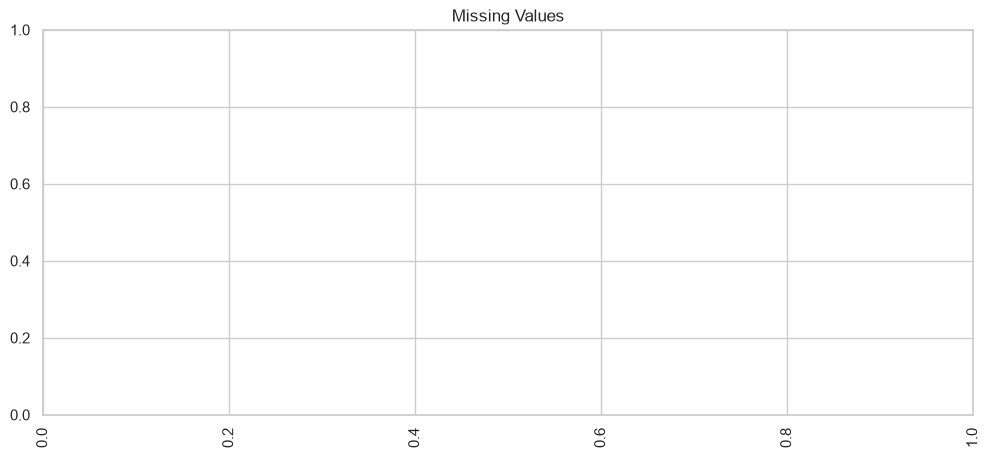

In [14]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.xticks(rotation=90)

plt.title("Missing Values")
plt.show()

In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['latitude', 'longitude', 'last_updated_epoch', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity',
       'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km',
       'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'moon_illumination'],
      dtype='object')

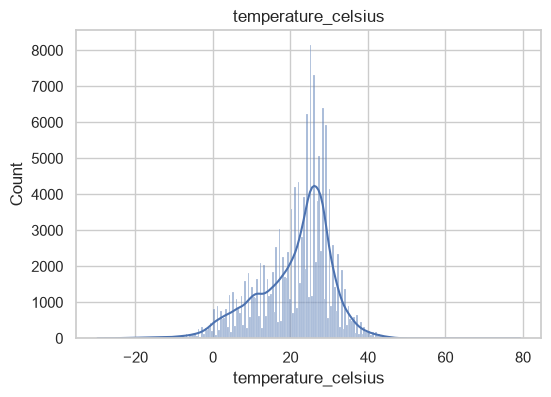

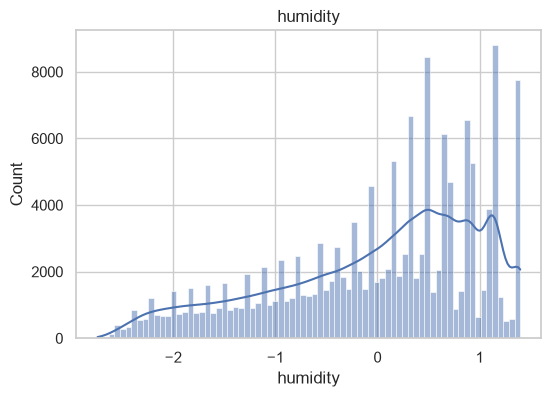

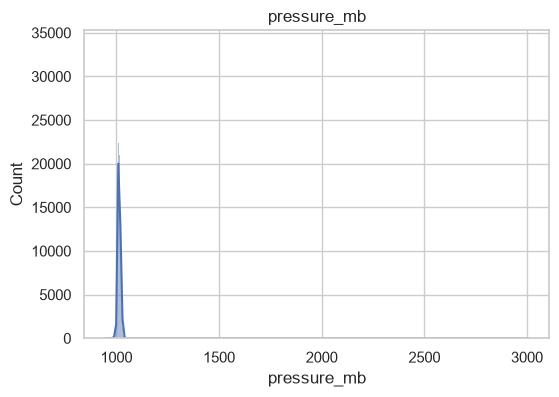

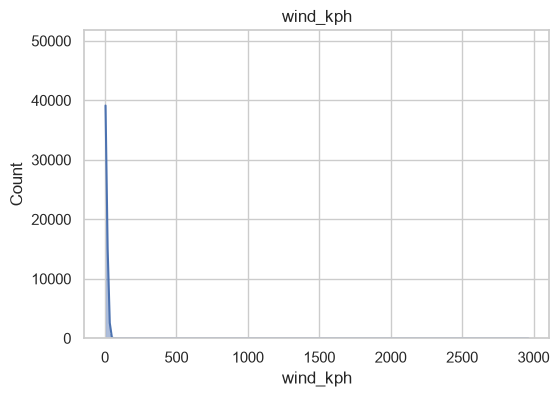

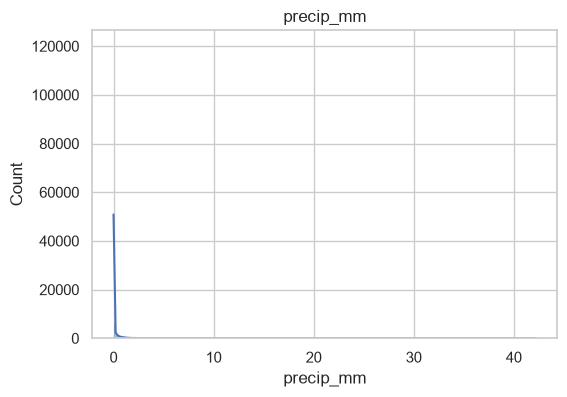

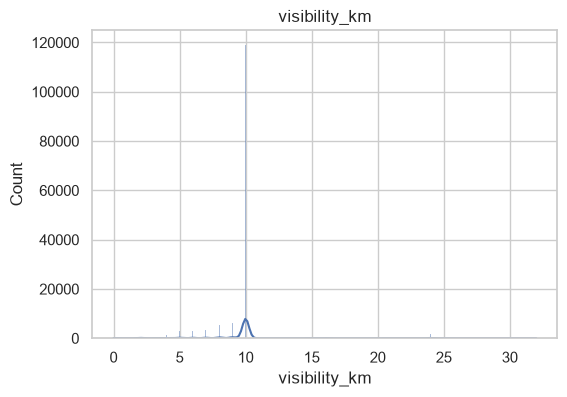

In [17]:
important = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "visibility_km"
]

for col in important:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

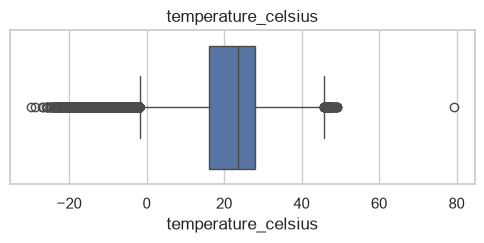

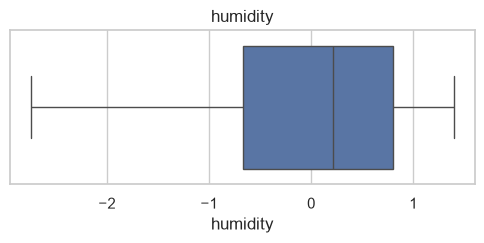

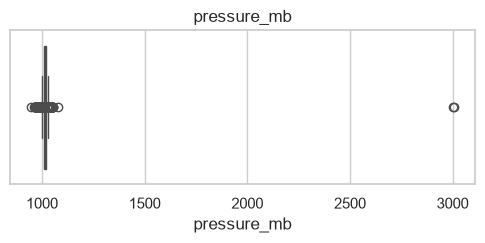

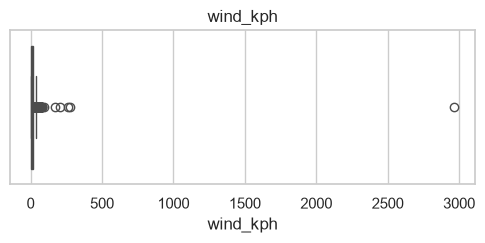

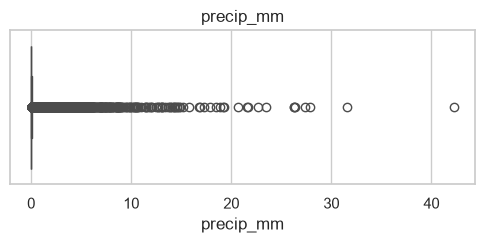

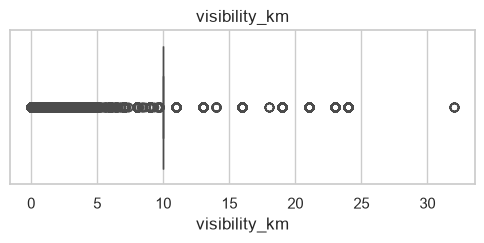

In [18]:
for col in important:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

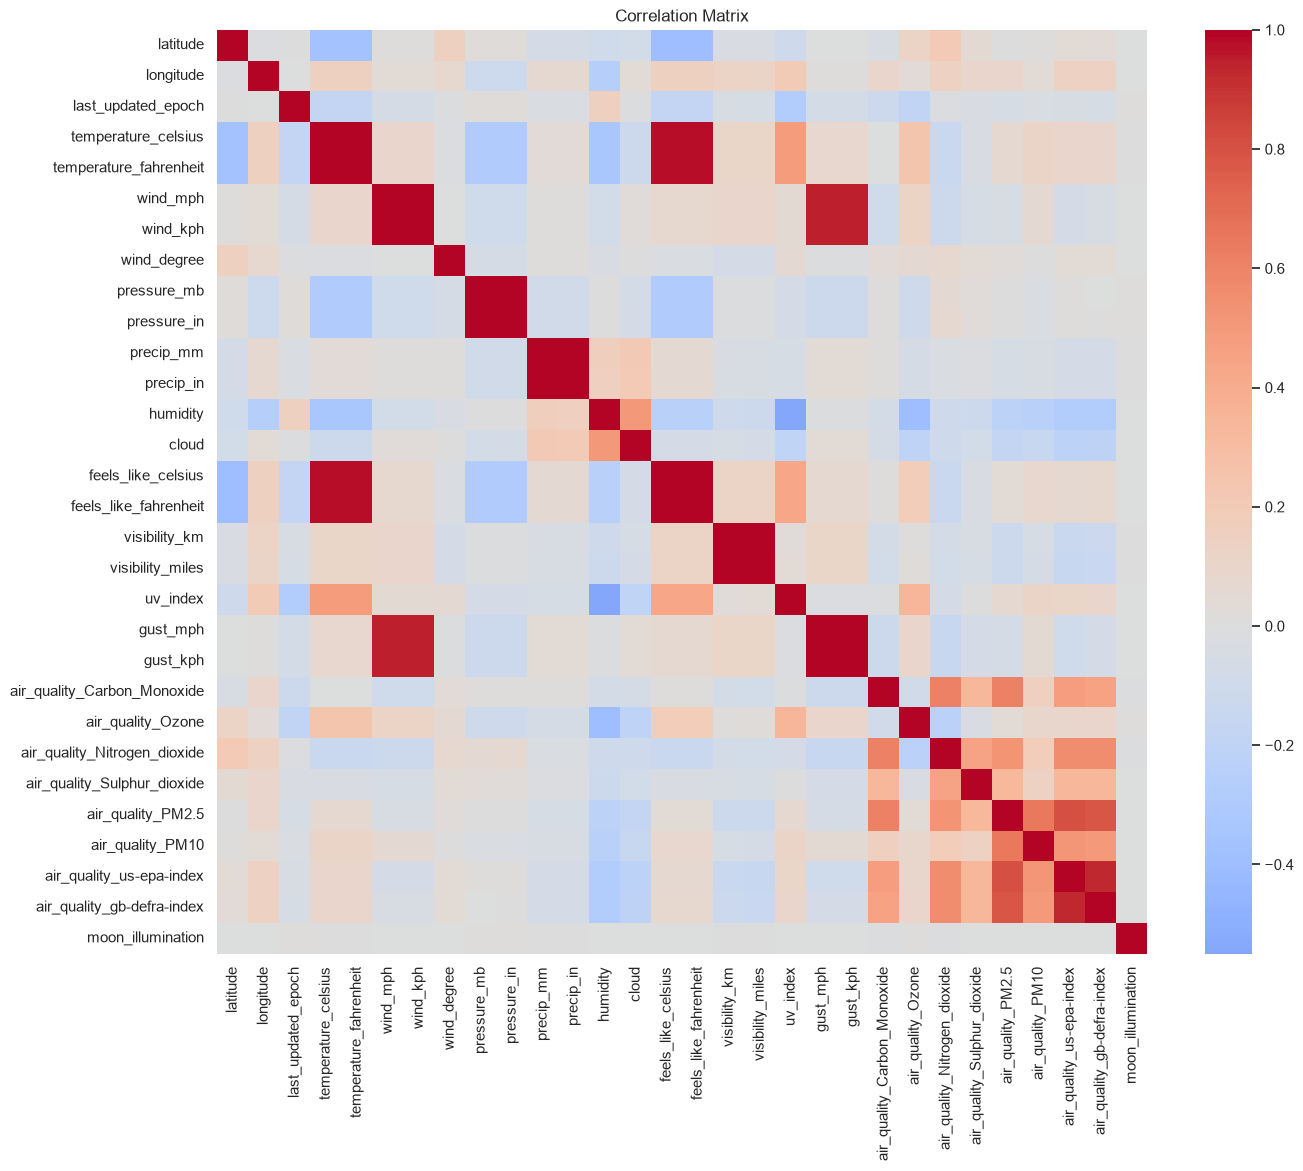

In [19]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(15,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

In [20]:
country_temp = (
    df.groupby("country")["temperature_celsius"]
      .mean()
      .sort_values(ascending=False)
)
country_temp

country
Saudi Arabien    45.000000
Marrocos         40.300000
Turkménistan     37.800000
Турция           34.000000
Qatar            32.452781
                   ...    
Andorra           8.818581
Norway            8.115326
Iceland           5.601294
Canada            5.467270
Mongolia          4.597933
Name: temperature_celsius, Length: 211, dtype: float64

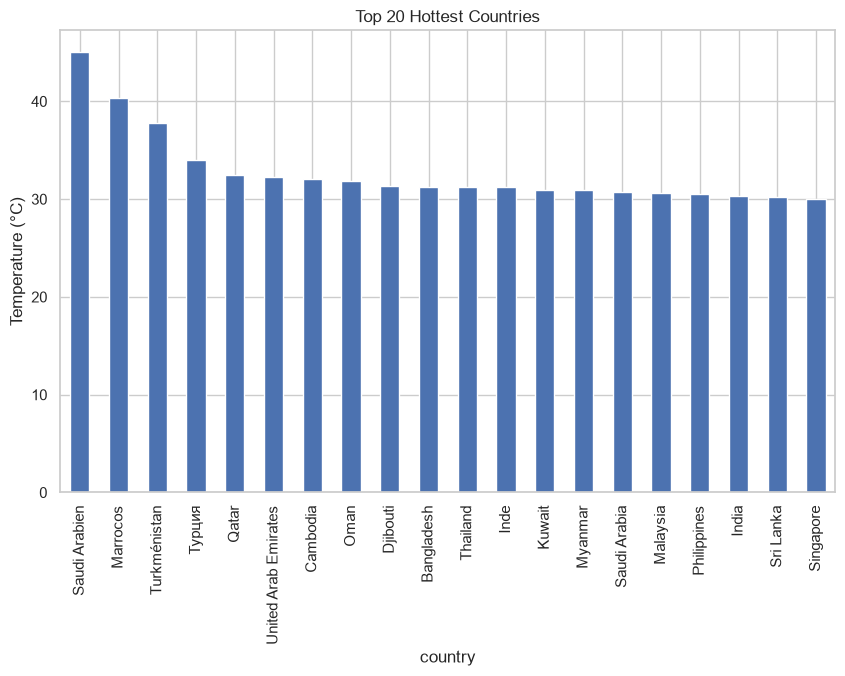

In [21]:
plt.figure(figsize=(10,6))
country_temp.head(20).plot(kind="bar")
plt.ylabel("Temperature (°C)")
plt.title("Top 20 Hottest Countries")
plt.show()

In [22]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

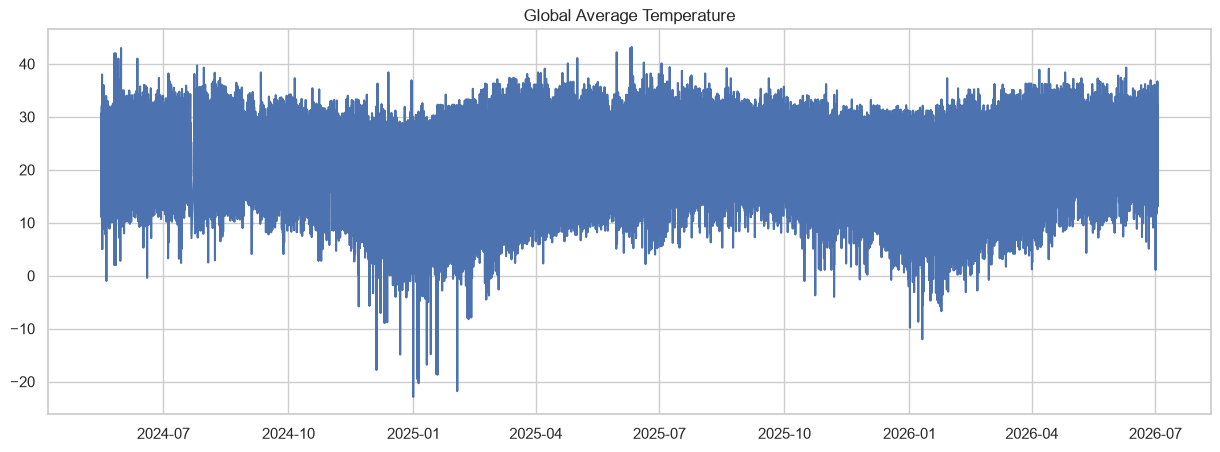

In [23]:
daily = (
    df.groupby("last_updated")["temperature_celsius"]
      .mean()
)
plt.figure(figsize=(15,5))
plt.plot(daily)
plt.title("Global Average Temperature")
plt.show()

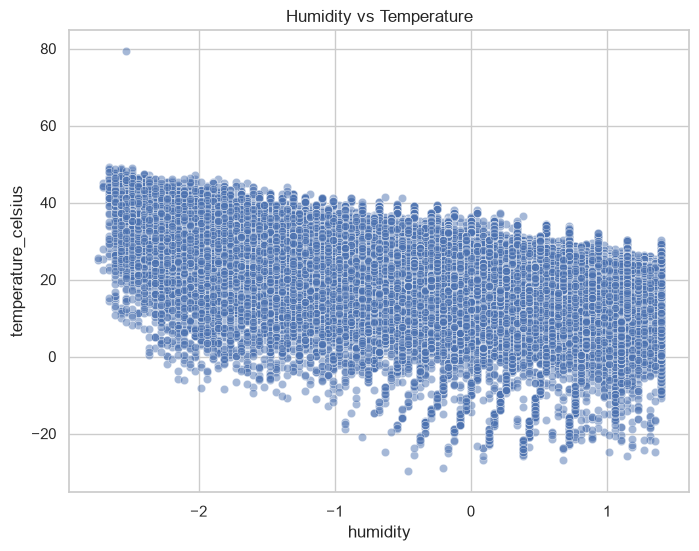

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="humidity",
    y="temperature_celsius",
    alpha=0.5
)
plt.title("Humidity vs Temperature")
plt.show()

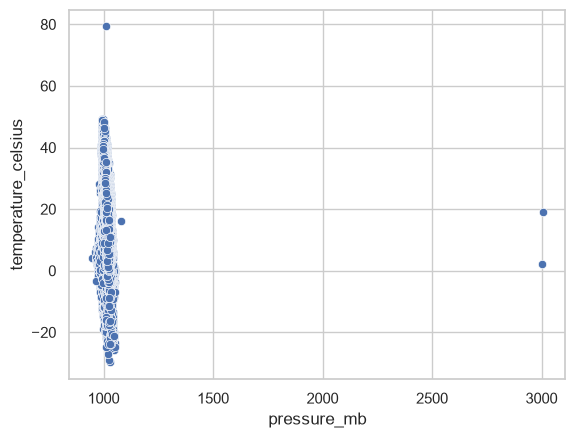

In [25]:
sns.scatterplot(
    data=df,
    x="pressure_mb",
    y="temperature_celsius"
)
plt.show()

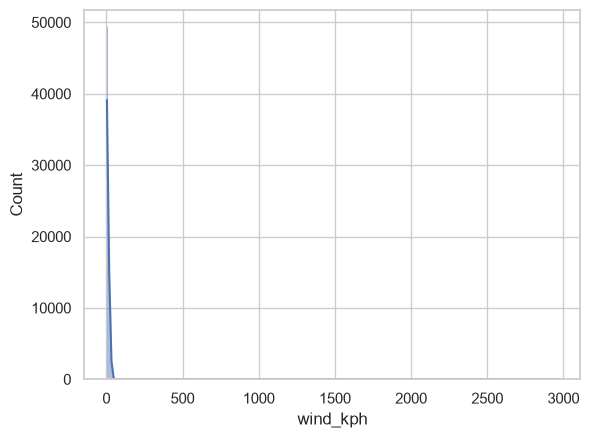

In [26]:
sns.histplot(df["wind_kph"], kde=True)
plt.show()

### Most common weather

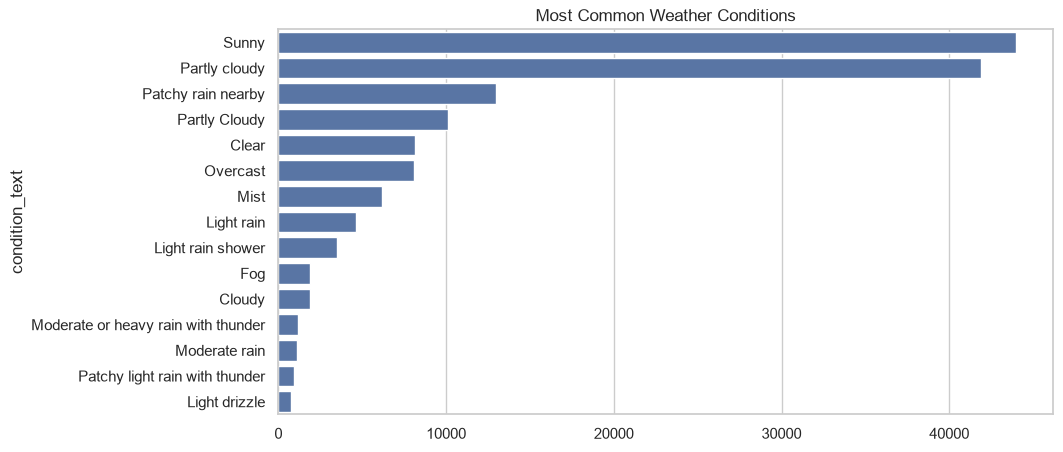

In [27]:
condition = (
    df["condition_text"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=condition.values,
    y=condition.index
)

plt.title("Most Common Weather Conditions")

plt.show()

### Air Quality Analysis

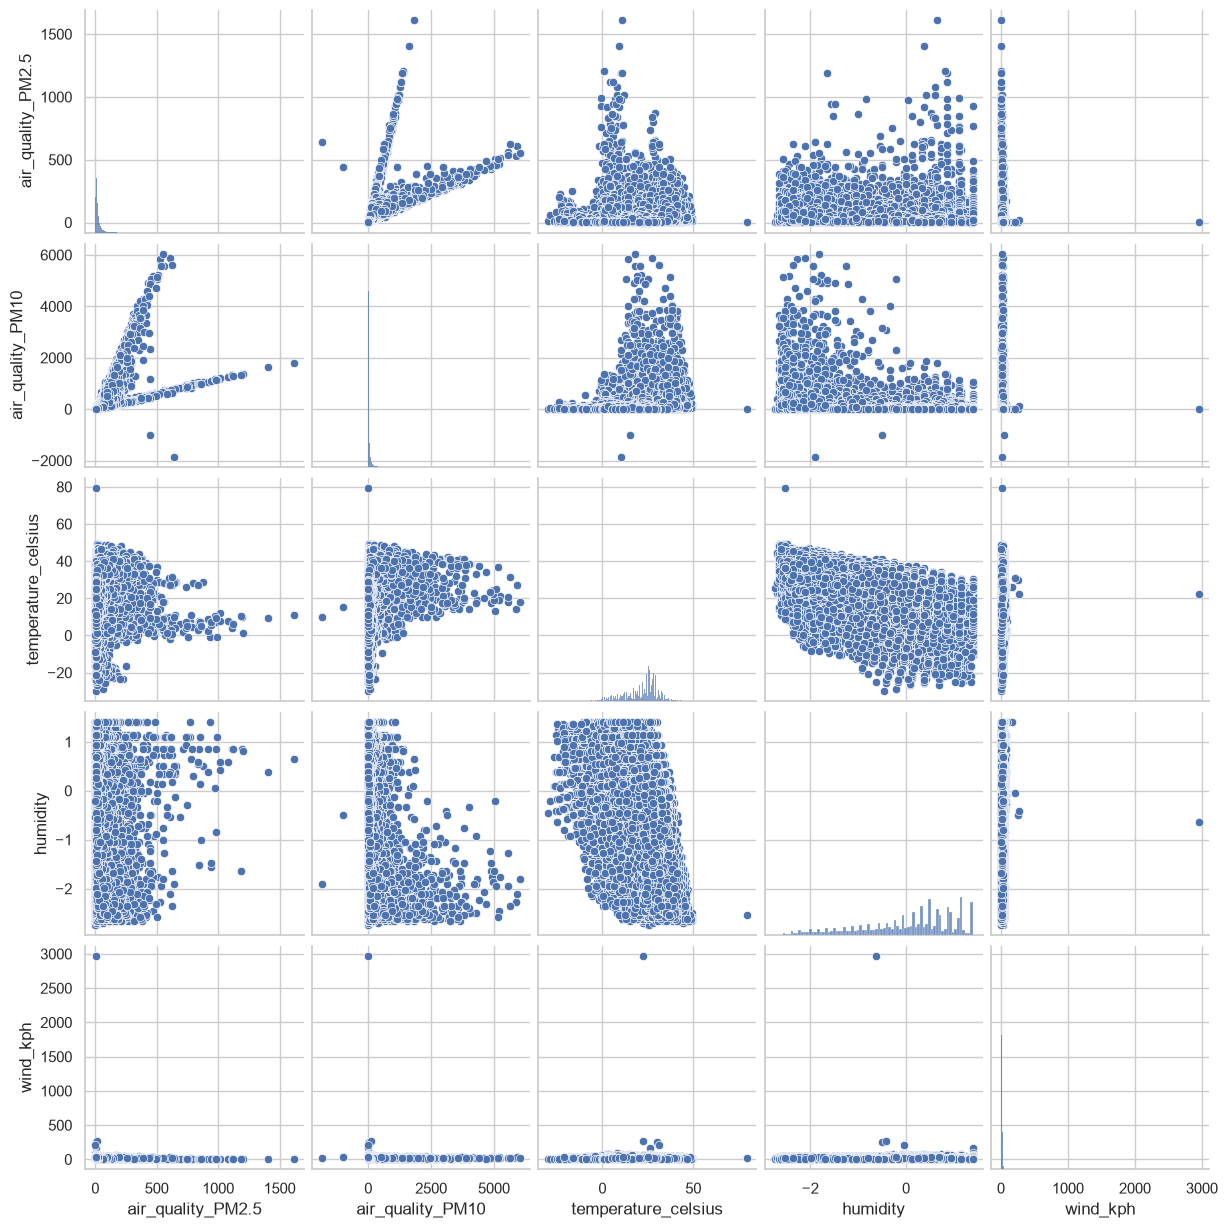

In [28]:
aq = [
    "air_quality_PM2.5",
    "air_quality_PM10",
    "temperature_celsius",
    "humidity",
    "wind_kph"
]

sns.pairplot(df[aq])
plt.show()

## Monthly Trend
### Extract month

In [29]:
df["month"] = df["last_updated"].dt.month
print(df["month"])

186       5
40        5
110       5
52        5
68        5
         ..
150783    7
150749    7
150718    7
150836    7
150808    7
Name: month, Length: 150855, dtype: int32


### Monthly average

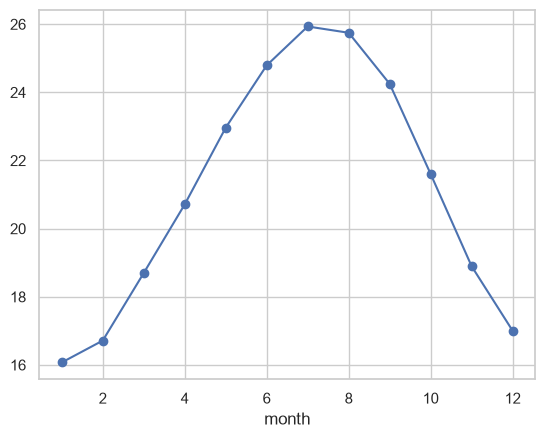

In [30]:
monthly = (
    df.groupby("month")["temperature_celsius"]
      .mean()
)

monthly.plot(marker="o")
plt.show()

### Geographical Analysis

In [31]:
fig = px.scatter_geo(
    df.sample(5000),
    lat="latitude",
    lon="longitude",
    color="temperature_celsius",
    hover_name="country"
)
fig.show()

In [32]:
print(df.columns.tolist())

['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination', 'month']


### Interactive World Map

In [33]:
avg_temp = (
    df.groupby("country")
      .temperature_celsius.mean()
      .reset_index()
)

fig = px.choropleth(
    avg_temp,
    locations="country",
    locationmode="country names",
    color="temperature_celsius",
    title="Average Temperature by Country"
)

fig.show()

/var/folders/xc/txpjt8jd7wz640wj70_c1g140000gn/T/ipykernel_35380/134959819.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


### Pairplot

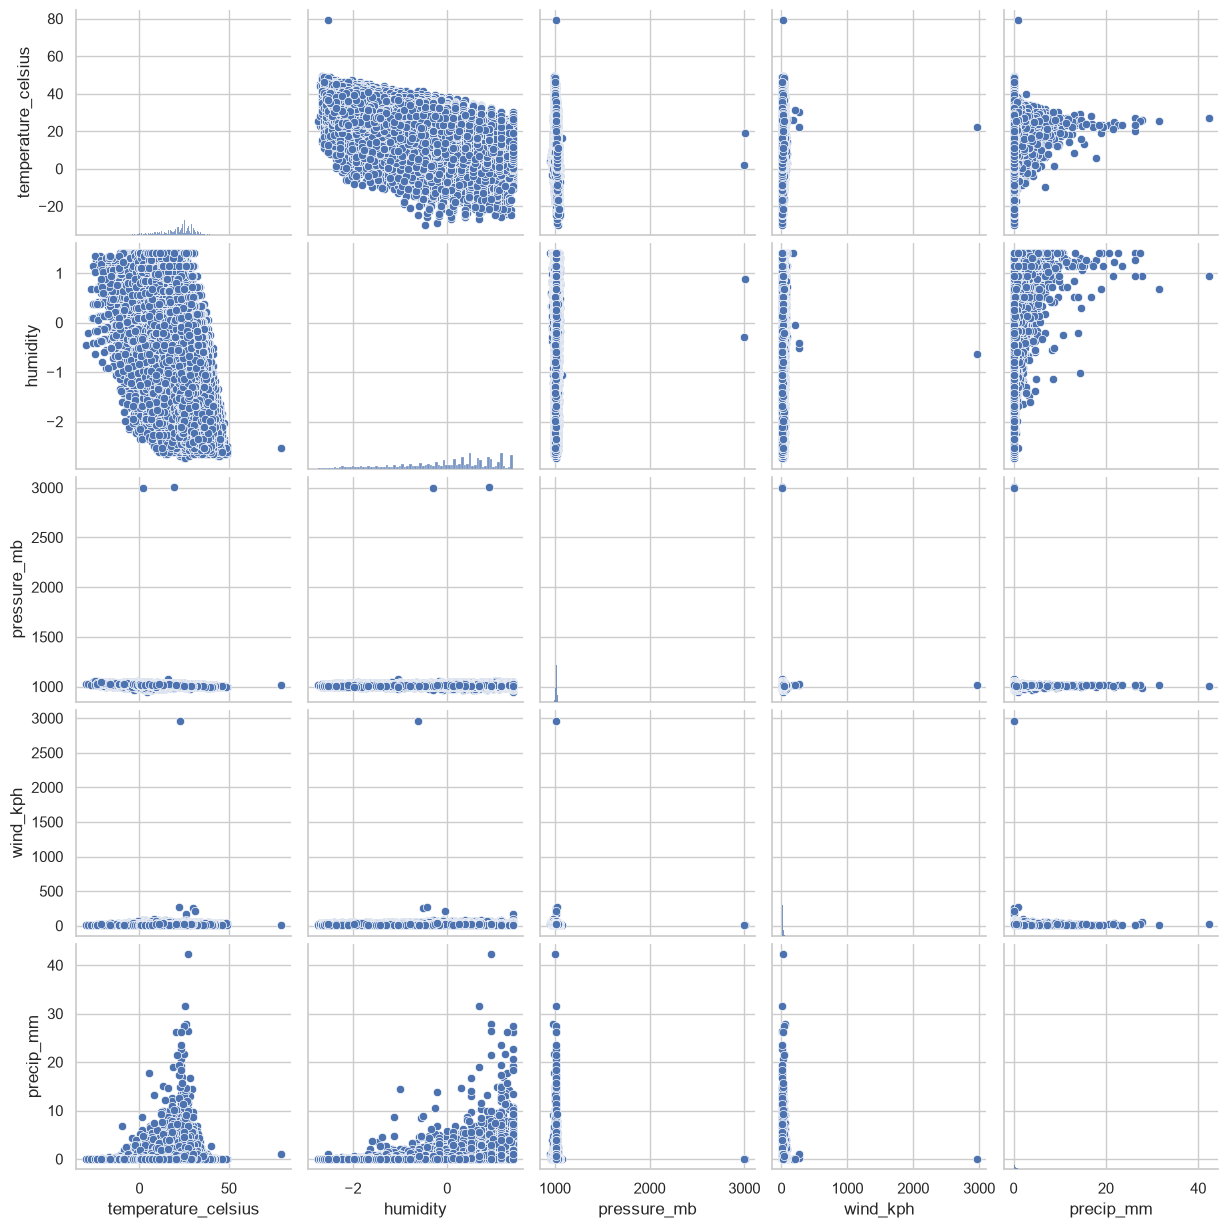

In [34]:
sns.pairplot(
    df[
        [
            "temperature_celsius",
            "humidity",
            "pressure_mb",
            "wind_kph",
            "precip_mm"
        ]
    ]
)
plt.show()

## Feature Engineering

In [35]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

In [36]:
df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["day_of_week"] = df["last_updated"].dt.dayofweek
df["hour"] = df["last_updated"].dt.hour
df["weekofyear"] = df["last_updated"].dt.isocalendar().week.astype(int)

In [37]:
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
})

### Time Series Preparation

In [38]:
target = "temperature_celsius"

drop_cols = [
    "temperature_celsius",
    "temperature_fahrenheit",      # Same information
    "feels_like_celsius",          # Highly correlated with target
    "feels_like_fahrenheit",
    "last_updated",                # if present
    "condition_text",              # We'll encode later if desired
    "country",
    "location_name",
    "timezone",
    "sunrise",
    "sunset",
    "moonrise",
    "moonset",
    "moon_phase",
    "wind_direction"
]

existing_drop = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=existing_drop)

y = df[target]

In [39]:
X.select_dtypes(include="object").columns

Index(['season'], dtype='object')

In [40]:
le = LabelEncoder()
X["season"] = le.fit_transform(X["season"])

In [41]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [42]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [43]:
def evaluate(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-"*30)
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [44]:
results = []

results.append(
    evaluate(
        "Linear Regression",
        y_test,
        pred_lr
    )
)


Linear Regression
------------------------------
MAE  : 5.668
RMSE : 7.048
R²   : 0.464


In [98]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

results.append(
    evaluate(
        "Random Forest",
        y_test,
        pred_rf
    )
)


Random Forest
------------------------------
MAE  : 2.504
RMSE : 3.539
R²   : 0.865


In [46]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

results.append(
    evaluate(
        "XGBoost",
        y_test,
        pred_xgb
    )
)


XGBoost
------------------------------
MAE  : 2.200
RMSE : 3.067
R²   : 0.898


In [47]:
results_df = pd.DataFrame(results)
results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,XGBoost,2.199615,3.067269,0.898485
1,Random Forest,2.506360,3.538849,0.864870
0,Linear Regression,5.667729,7.047663,0.464058


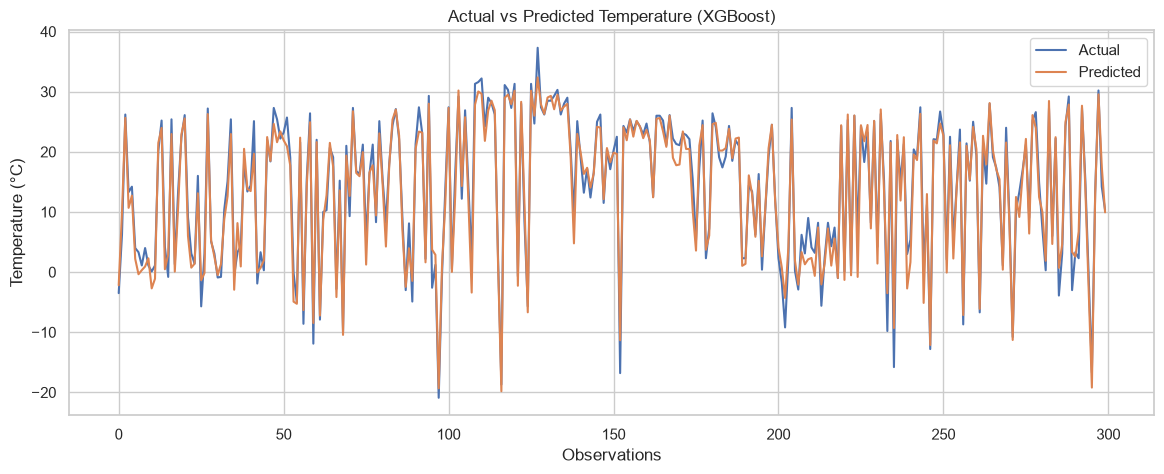

In [48]:
plt.figure(figsize=(14,5))

plt.plot(y_test.values[:300], label="Actual")
plt.plot(pred_xgb[:300], label="Predicted")

plt.title("Actual vs Predicted Temperature (XGBoost)")
plt.xlabel("Observations")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

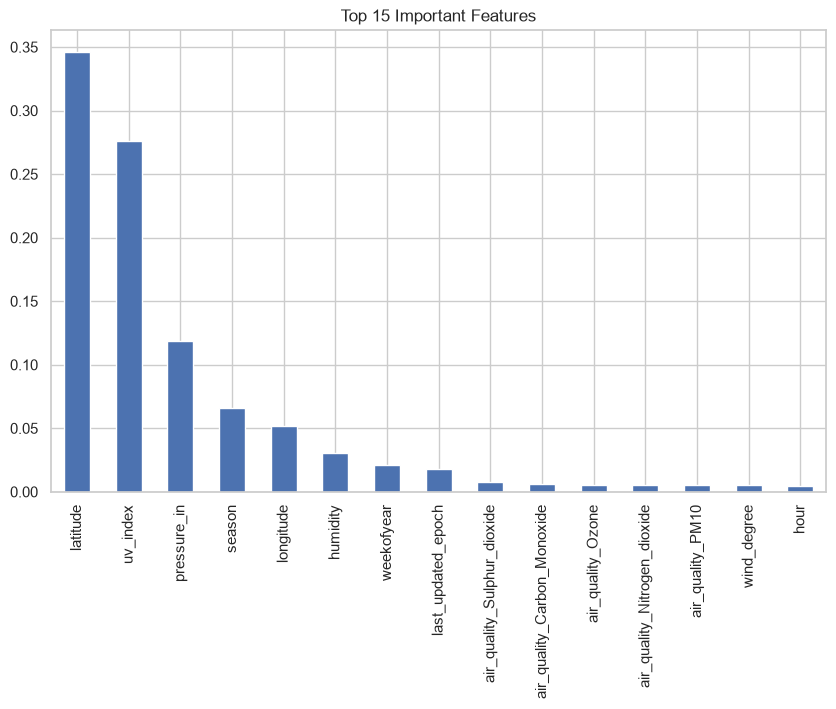

In [49]:
importance = (
    pd.Series(
        rf.feature_importances_,
        index=X.columns
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
importance.head(15).plot(kind="bar")
plt.title("Top 15 Important Features")
plt.show()

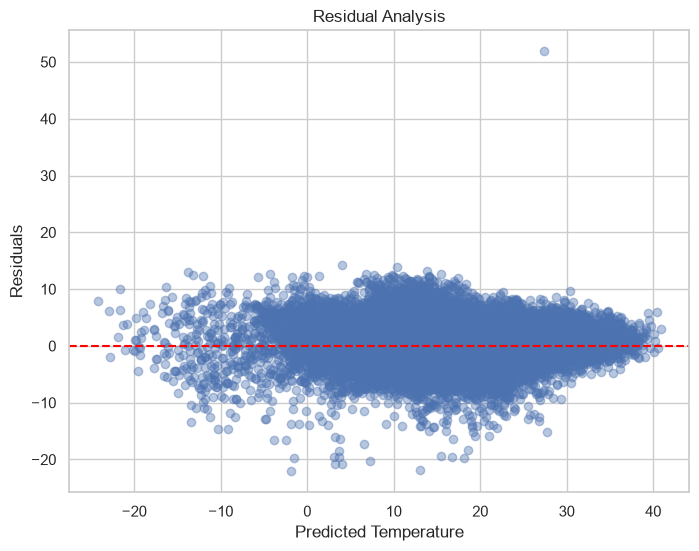

In [50]:
residuals = y_test - pred_xgb

plt.figure(figsize=(8,6))

plt.scatter(pred_xgb, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Temperature")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

Three regression models were evaluated to predict temperature using weather-related features. Linear Regression served as a baseline model but achieved the lowest performance (R² = 0.464), indicating that the relationship between weather variables and temperature is not strictly linear. Tree-based ensemble methods performed substantially better. Random Forest achieved an R² of 0.865, while XGBoost delivered the highest accuracy with an R² of 0.898, the lowest MAE (2.20°C), and the lowest RMSE (3.07°C). Based on these results, XGBoost was selected as the final forecasting model.

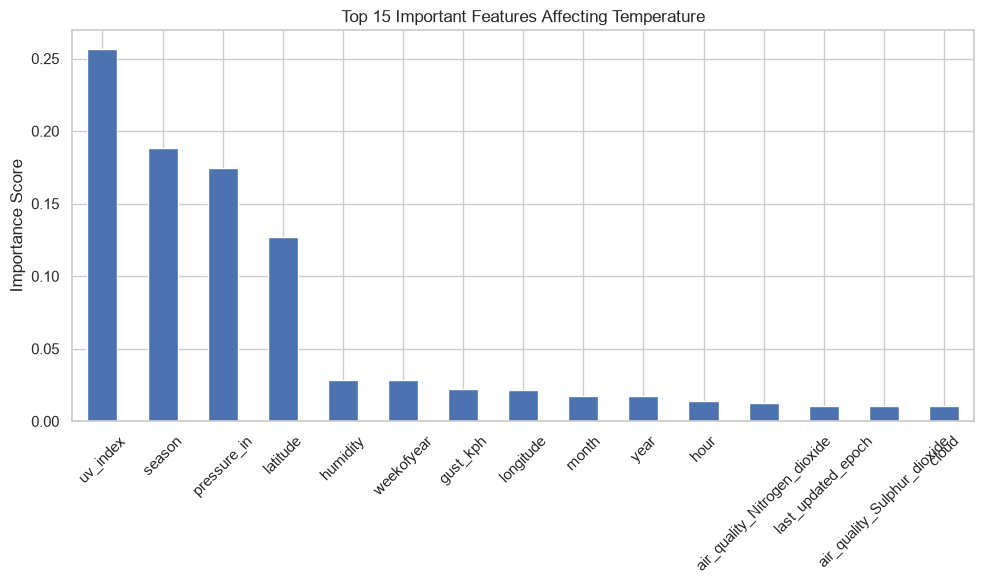

In [51]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(15).plot(kind="bar")
plt.title("Top 15 Important Features Affecting Temperature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
importance.head(15)

uv_index                        0.256516
season                          0.188394
pressure_in                     0.174231
latitude                        0.127075
humidity                        0.028568
weekofyear                      0.028456
gust_kph                        0.022316
longitude                       0.021826
month                           0.017366
year                            0.017200
hour                            0.014199
air_quality_Nitrogen_dioxide    0.012384
last_updated_epoch              0.010472
air_quality_Sulphur_dioxide     0.010466
cloud                           0.010422
dtype: float32

### SHAP Analysis

In [53]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

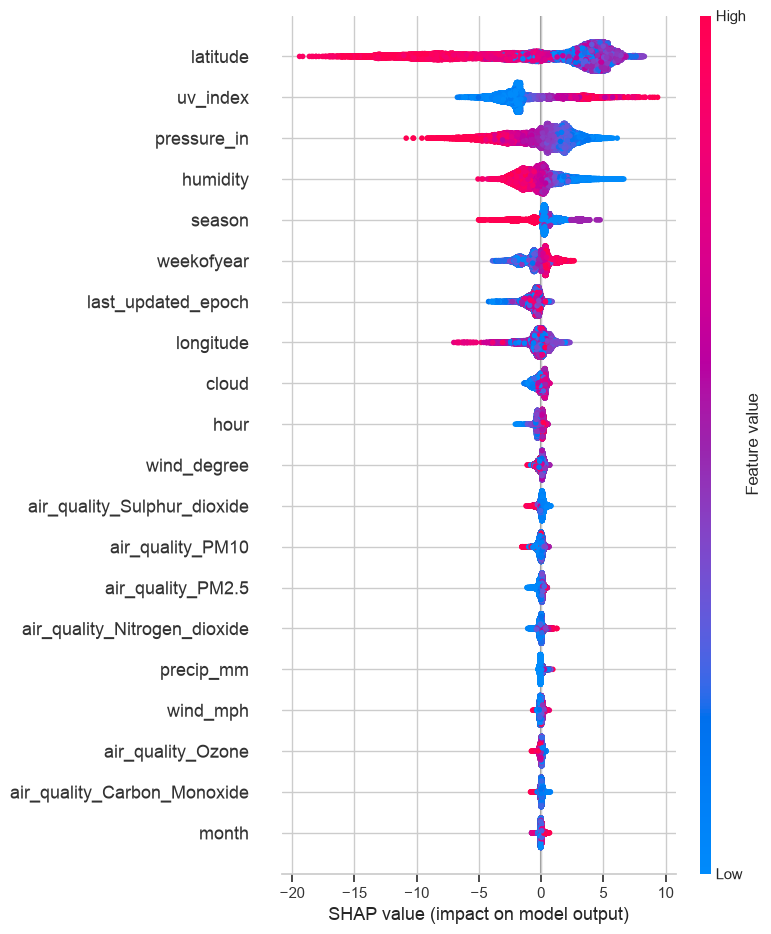

In [54]:
shap.summary_plot(shap_values, X_test)

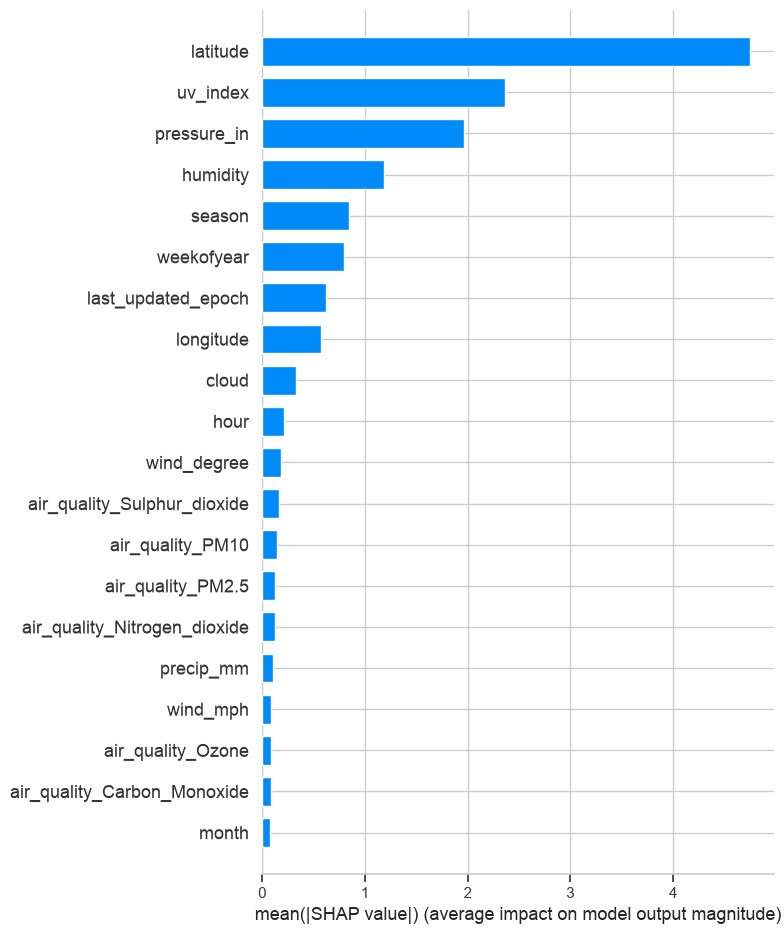

In [55]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

### Anomaly Detection

In [56]:
from sklearn.ensemble import IsolationForest

features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm"
]

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["anomaly"] = iso.fit_predict(df[features])

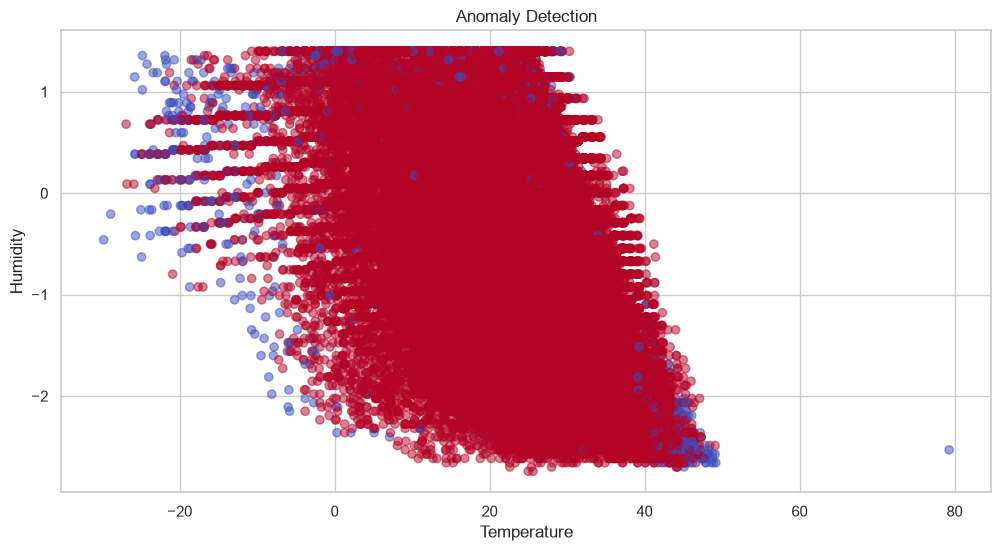

In [57]:
plt.figure(figsize=(12,6))

plt.scatter(
    df["temperature_celsius"],
    df["humidity"],
    c=df["anomaly"],
    cmap="coolwarm",
    alpha=0.5
)

plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Anomaly Detection")
plt.show()

In [85]:
df["anomaly"] = iso.fit_predict(X)

In [58]:
df["anomaly"].value_counts()

anomaly
 1    147837
-1      3018
Name: count, dtype: int64

In [59]:
3018 / 150855

0.02000596599383514

In [60]:
anomalies = df[df["anomaly"] == -1]
anomalies.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,moon_phase,moon_illumination,month,year,day,day_of_week,hour,weekofyear,season,anomaly
317,Netherlands,Amsterdam,52.37,4.89,Europe/Amsterdam,-1.731280,2024-05-16 16:00:00,20.0,68.0,Partly cloudy,...,Waxing Gibbous,0.137164,5,2024,16,3,16,20,Spring,-1
181,Tuvalu,Funafuti,-8.52,179.22,Pacific/Funafuti,-1.732255,2024-05-16 20:45:00,26.0,78.8,Moderate rain at times,...,Waxing Gibbous,0.137164,5,2024,16,3,20,20,Spring,-1
176,Tonga,Nuku`Aloia,-21.13,-175.20,Pacific/Tongatapu,-1.732255,2024-05-16 21:45:00,23.0,73.4,Moderate rain,...,Waxing Gibbous,0.137164,5,2024,16,3,21,20,Spring,-1
219,Brunei Darussalam,Bandar Seri Begawan,4.88,114.93,Asia/Brunei,-1.731280,2024-05-16 22:00:00,27.0,80.6,Patchy light rain with thunder,...,Waxing Gibbous,0.137164,5,2024,16,3,22,20,Spring,-1
371,Tonga,Nuku`Aloia,-21.13,-175.20,Pacific/Tongatapu,-1.731233,2024-05-17 03:15:00,23.0,73.4,Light rain,...,Waxing Gibbous,0.137164,5,2024,17,4,3,20,Spring,-1


In [61]:
anomalies.describe()

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,month,year,day,day_of_week,hour,weekofyear,anomaly
count,3018.000000,3018.000000,3018.000000,3018,3018.000000,3018.000000,3018.000000,3018.000000,3018.000000,3018.000000,...,3018.000000,3018.000000,3018.000000,3018.000000,3018.000000,3018.000000,3018.000000,3018.000000,3018.000000,3018.0
mean,25.968252,37.068260,-0.076995,2025-05-22 19:54:05.129224704,17.092346,62.769848,12.516070,20.144665,0.225209,1007.825050,...,-0.188145,-0.147825,-0.001079,6.337309,2024.903910,15.800199,3.009940,12.060636,25.505633,-1.0
min,-41.300000,-175.200000,-1.732255,2024-05-16 16:00:00,-29.800000,-21.600000,2.200000,3.600000,-1.626585,947.000000,...,-0.725665,-0.642642,-1.428753,1.000000,2024.000000,1.000000,0.000000,0.000000,1.000000,-1.0
25%,7.100000,-3.143650,-0.937652,2024-11-10 18:33:45,7.300000,45.100000,4.500000,7.200000,-0.631829,1000.000000,...,-0.725665,-0.642642,-0.973214,3.000000,2024.000000,8.000000,1.000000,8.000000,11.000000,-1.0
50%,29.366700,27.566700,-0.033858,2025-06-01 12:15:00,21.700000,71.000000,10.700000,17.300000,0.314639,1008.000000,...,-0.725665,-0.642642,-0.005192,6.000000,2025.000000,16.000000,3.000000,12.000000,26.000000,-1.0
75%,47.916700,96.166700,0.852952,2025-12-17 06:15:00,27.075000,80.700000,18.600000,29.900000,1.087265,1014.000000,...,0.353667,-0.226201,0.934358,9.000000,2025.000000,24.000000,5.000000,16.000000,38.000000,-1.0
max,65.300000,179.220000,1.730847,2026-07-02 08:45:00,79.300000,174.700000,169.100000,272.200000,1.840576,1053.000000,...,4.670998,3.105324,1.418369,12.000000,2026.000000,31.000000,6.000000,23.000000,52.000000,-1.0
std,25.783325,72.858752,0.989965,NaN,15.842630,28.516609,9.278915,14.929662,0.983107,12.448657,...,1.009358,0.998168,0.979543,3.537789,0.738661,8.911128,1.969413,5.044052,15.377068,0.0


### Ensemble Model

In [62]:
ensemble_pred = (
    pred_rf +
    pred_xgb
) / 2

In [63]:
results.append(
    evaluate(
        "Ensemble",
        y_test,
        ensemble_pred
    )
)


Ensemble
------------------------------
MAE  : 2.216
RMSE : 3.111
R²   : 0.896


In [64]:
results_df = pd.DataFrame(results)
results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,XGBoost,2.199615,3.067269,0.898485
3,Ensemble,2.216048,3.110537,0.895601
1,Random Forest,2.506360,3.538849,0.864870
0,Linear Regression,5.667729,7.047663,0.464058


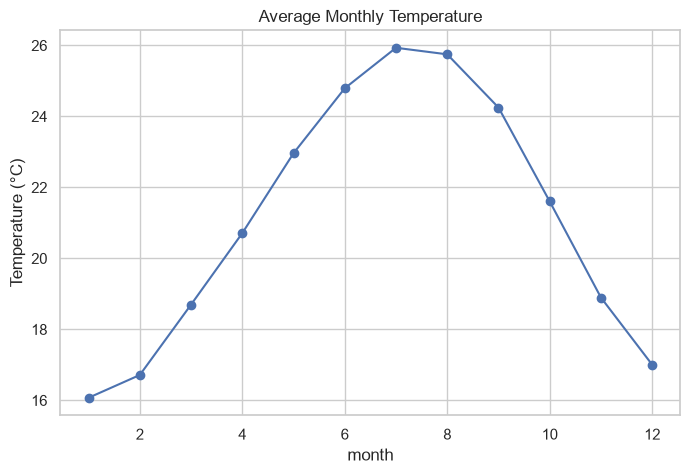

In [65]:
monthly = (
    df.groupby("month")["temperature_celsius"]
      .mean()
)

plt.figure(figsize=(8,5))
monthly.plot(marker="o")
plt.title("Average Monthly Temperature")
plt.ylabel("Temperature (°C)")
plt.show()

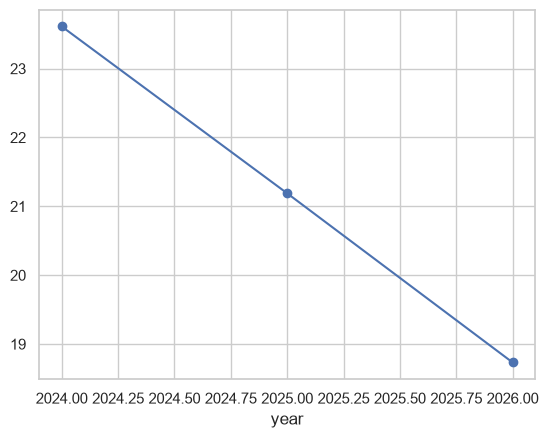

In [66]:
yearly = (
    df.groupby("year")["temperature_celsius"]
      .mean()
)
yearly.plot(marker="o")
plt.show()

### Air Quality Analysis

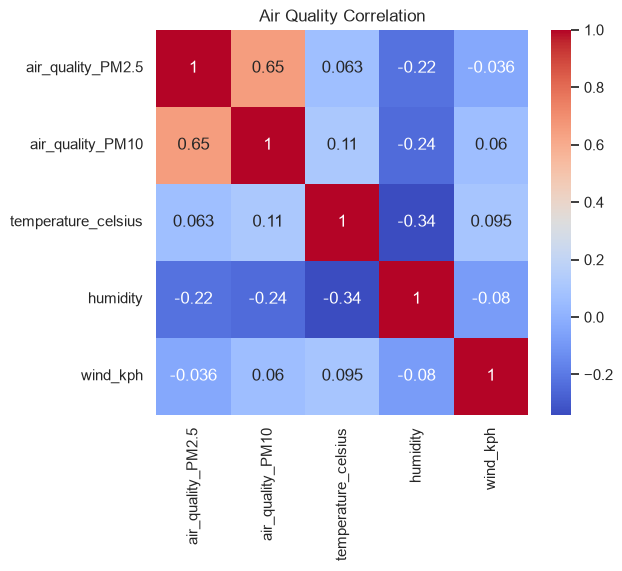

In [67]:
aq = [
    "air_quality_PM2.5",
    "air_quality_PM10",
    "temperature_celsius",
    "humidity",
    "wind_kph"
]

corr = df[aq].corr()
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Air Quality Correlation")
plt.show()

### Spatial Analysis

In [68]:
fig = px.scatter_geo(
    df.sample(5000),
    lat="latitude",
    lon="longitude",
    color="temperature_celsius",
    hover_name="country",
    title="Global Temperature Distribution"
)

fig.show()

In [69]:
avg_temp = (
    df.groupby("country")["temperature_celsius"]
      .mean()
      .reset_index()
)

fig = px.choropleth(
    avg_temp,
    locations="country",
    locationmode="country names",
    color="temperature_celsius",
    title="Average Temperature by Country"
)

fig.show()

/var/folders/xc/txpjt8jd7wz640wj70_c1g140000gn/T/ipykernel_35380/2328704458.py:7: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


### Final Model Comparison Table

In [70]:
results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,XGBoost,2.199615,3.067269,0.898485
3,Ensemble,2.216048,3.110537,0.895601
1,Random Forest,2.506360,3.538849,0.864870
0,Linear Regression,5.667729,7.047663,0.464058


### Interpretation
- XGBoost achieved the best performance across all evaluation metrics.
- Random Forest also performed well but was consistently less accurate than XGBoost.
- The ensemble model did not improve performance over XGBoost alone. This is a perfectly valid outcome because averaging predictions from a weaker model (Random Forest) slightly reduced the performance of the stronger model (XGBoost).
- Linear Regression served as a useful baseline but struggled because the relationship between weather variables and temperature is highly nonlinear.

XGBoost achieved the highest predictive accuracy with an R² of 0.898, indicating that approximately 90% of the variance in temperature was explained by the model. The ensemble approach did not outperform XGBoost, suggesting that XGBoost alone captured the underlying patterns effectively.